# Jet + Track AE/VAE — pipeline pulita

Questo notebook crea da zero dataset preprocessati usando sia feature **jet-level** sia feature **track-level**, poi confronta:

- Autoencoder classico, AE;
- Variational Autoencoder, VAE.

L'obiettivo è capire se l'AUC sospettosamente alta nasce dal preprocessing, dalle feature, o dal modello.

Di default il notebook:
- usa `X_jets + aggregate(X_tracks)`;
- esclude `displacedPtFraction`;
- filtra il training su background-like se `y` o `meta_isDisplaced` sono disponibili;
- valuta il signal usando solo `meta_isDisplaced == 1`, se disponibile.

## 1. Import e GPU

In [8]:
from pathlib import Path
import json
import numpy as np
import h5py
import yaml
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split

from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

np.random.seed(42)
torch.manual_seed(42)

print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)
print("GPU count:", torch.cuda.device_count())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Torch: 2.12.0+cu126
CUDA available: True
CUDA version: 12.6
GPU count: 1
GPU: NVIDIA GeForce RTX 4050 Laptop GPU
Using device: cuda


## 2. Path

In [9]:
RAW_DIR = Path(".")
PROCESSED_DIR = Path("processed_clean")
OUTPUT_DIR = Path("outputs_clean")

PROCESSED_DIR.mkdir(exist_ok=True)
OUTPUT_DIR.mkdir(exist_ok=True)

raw_files = {
    "val": RAW_DIR / "pp_output_val.h5",
    "test_background": RAW_DIR / "pp_output_test_background.h5",
    "test_signal": RAW_DIR / "pp_output_test_signal.h5",
}

norm_path = RAW_DIR / "norm_dict.yaml"

for name, path in raw_files.items():
    print(name, "->", path, "exists:", path.exists())

print("norm_dict ->", norm_path, "exists:", norm_path.exists())

val -> pp_output_val.h5 exists: True
test_background -> pp_output_test_background.h5 exists: True
test_signal -> pp_output_test_signal.h5 exists: True
norm_dict -> norm_dict.yaml exists: True


## 3. Carica normalizzazione

In [10]:
def load_yaml(path):
    with open(path, "r") as f:
        return yaml.safe_load(f)

norm_dict = load_yaml(norm_path)

print("norm_dict keys:", norm_dict.keys())
print("jet features in norm_dict:", len(norm_dict.get("jets", {})))
print("track features in norm_dict:", len(norm_dict.get("tracks", {})))

norm_dict keys: dict_keys(['jets', 'tracks'])
jet features in norm_dict: 15
track features in norm_dict: 26


## 4. Feature scelte

In [11]:
USE_DISPLACED_PT_FRACTION = False

jet_features_base = [
    "pt",
    "eta",
    "mass",
    "energy",
    "Qw_clusterSoftDrop",
    "C2_clusterSoftDrop",
    "D2_clusterSoftDrop",
    "Tau1_clusterSoftDrop",
    "Tau2_clusterSoftDrop",
    "Tau3_clusterSoftDrop",
    "Tau21_clusterSoftDrop",
    "Tau32_clusterSoftDrop",
    "ECF1_clusterSoftDrop",
    "ECF2_clusterSoftDrop",
]

if USE_DISPLACED_PT_FRACTION:
    jet_features = [
        "pt",
        "eta",
        "mass",
        "energy",
        "displacedPtFraction",
        "Qw_clusterSoftDrop",
        "C2_clusterSoftDrop",
        "D2_clusterSoftDrop",
        "Tau1_clusterSoftDrop",
        "Tau2_clusterSoftDrop",
        "Tau3_clusterSoftDrop",
        "Tau21_clusterSoftDrop",
        "Tau32_clusterSoftDrop",
        "ECF1_clusterSoftDrop",
        "ECF2_clusterSoftDrop",
    ]
else:
    jet_features = jet_features_base

track_features = [
    "d0",
    "z0SinTheta",
    "dphi",
    "deta",
    "pt_log1p",
    "radiusOfFirstHit",
    "numberOfPixelHits",
    "numberOfSCTHits",
    "numberOfSCTHoles",
    "numberOfInnermostPixelLayerHits",
    "numberOfPixelSharedHits",
    "numberOfSCTSharedHits",
]

print("USE_DISPLACED_PT_FRACTION:", USE_DISPLACED_PT_FRACTION)
print("jet_features:", jet_features)
print("track_features:", track_features)
print("n jet features:", len(jet_features))
print("n track features:", len(track_features))

USE_DISPLACED_PT_FRACTION: False
jet_features: ['pt', 'eta', 'mass', 'energy', 'Qw_clusterSoftDrop', 'C2_clusterSoftDrop', 'D2_clusterSoftDrop', 'Tau1_clusterSoftDrop', 'Tau2_clusterSoftDrop', 'Tau3_clusterSoftDrop', 'Tau21_clusterSoftDrop', 'Tau32_clusterSoftDrop', 'ECF1_clusterSoftDrop', 'ECF2_clusterSoftDrop']
track_features: ['d0', 'z0SinTheta', 'dphi', 'deta', 'pt_log1p', 'radiusOfFirstHit', 'numberOfPixelHits', 'numberOfSCTHits', 'numberOfSCTHoles', 'numberOfInnermostPixelLayerHits', 'numberOfPixelSharedHits', 'numberOfSCTSharedHits']
n jet features: 14
n track features: 12


## 5. Controllo feature disponibili

In [12]:
def get_fields(file_path, dataset_name):
    with h5py.File(file_path, "r") as f:
        return set(f[dataset_name].dtype.names)

jet_fields = {name: get_fields(path, "jets") for name, path in raw_files.items()}
track_fields = {name: get_fields(path, "tracks") for name, path in raw_files.items()}

for name in raw_files:
    missing_jets = set(jet_features) - jet_fields[name]
    missing_tracks = set(track_features) - track_fields[name]

    print("\n", name)
    print("missing jet features:", missing_jets)
    print("missing track features:", missing_tracks)

    if missing_jets or missing_tracks:
        raise ValueError(f"Feature mancanti in {name}. Correggi jet_features o track_features.")


 val
missing jet features: set()
missing track features: set()

 test_background
missing jet features: set()
missing track features: set()

 test_signal
missing jet features: set()
missing track features: set()


## 6. Funzioni preprocessing HDF5 -> NPZ

In [13]:
def get_norm_stats(norm_dict, object_type, feature, fallback_values=None, fallback_mask=None):
    # Restituisce mean/std; se manca in norm_dict usa fallback_values.
    if object_type in norm_dict and feature in norm_dict[object_type]:
        mean = float(norm_dict[object_type][feature]["mean"])
        std = float(norm_dict[object_type][feature]["std"])
        std = max(std, 1e-8)
        return mean, std, "norm_dict"

    if fallback_values is None:
        raise KeyError(f"{object_type}.{feature} non trovato in norm_dict e fallback assente")

    if fallback_mask is not None:
        values = fallback_values[fallback_mask]
    else:
        values = fallback_values

    mean = float(np.nanmean(values))
    std = float(np.nanstd(values))
    std = max(std, 1e-8)
    return mean, std, "computed"


def build_jet_track_dataset(file_path, jet_features, track_features, norm_dict, max_jets=None, verbose=True):
    file_path = Path(file_path)

    if verbose:
        print("\n" + "=" * 100)
        print("Processing:", file_path)
        print("=" * 100)

    with h5py.File(file_path, "r") as f:
        jets = f["jets"]
        tracks = f["tracks"]

        n_total = jets.shape[0]
        n = n_total if max_jets is None else min(max_jets, n_total)
        n_tracks = tracks.shape[1]

        if verbose:
            print("Total jets:", n_total)
            print("Jets used:", n)
            print("Tracks per jet:", n_tracks)

        track_mask = np.asarray(tracks["valid"][:n], dtype=bool)

        X_jets = np.empty((n, len(jet_features)), dtype=np.float32)
        norm_stats_jets = {}

        for i, feat in enumerate(jet_features):
            x = np.asarray(jets[feat][:n], dtype=np.float32)
            mean, std, source = get_norm_stats(norm_dict, "jets", feat, fallback_values=x)
            x = (x - mean) / std
            np.nan_to_num(x, copy=False, nan=0.0, posinf=0.0, neginf=0.0)
            X_jets[:, i] = x
            norm_stats_jets[feat] = {"mean": mean, "std": std, "source": source}

        X_tracks = np.empty((n, n_tracks, len(track_features)), dtype=np.float32)
        norm_stats_tracks = {}

        for i, feat in enumerate(track_features):
            x = np.asarray(tracks[feat][:n], dtype=np.float32)
            mean, std, source = get_norm_stats(
                norm_dict,
                "tracks",
                feat,
                fallback_values=x,
                fallback_mask=track_mask,
            )
            x = (x - mean) / std
            np.nan_to_num(x, copy=False, nan=0.0, posinf=0.0, neginf=0.0)
            x[~track_mask] = 0.0
            X_tracks[:, :, i] = x
            norm_stats_tracks[feat] = {"mean": mean, "std": std, "source": source}

        metadata = {}
        for key in ["isDisplaced", "flavour_label", "mcEventWeight", "eventNumber"]:
            if key in jets.dtype.names:
                metadata[key] = np.asarray(jets[key][:n])

        filename = file_path.name.lower()
        if "background" in filename:
            y = np.zeros(n, dtype=np.int64)
        elif "signal" in filename:
            y = np.ones(n, dtype=np.int64)
        elif "isDisplaced" in metadata:
            y = metadata["isDisplaced"].astype(np.int64)
        else:
            y = None

    if verbose:
        print("X_jets:", X_jets.shape, X_jets.dtype)
        print("X_tracks:", X_tracks.shape, X_tracks.dtype)
        print("track_mask:", track_mask.shape, track_mask.dtype)
        print("finite X_jets:", np.isfinite(X_jets).all())
        print("finite X_tracks:", np.isfinite(X_tracks).all())
        print("invalid tracks zero:", np.allclose(X_tracks[~track_mask], 0.0))
        if y is not None:
            print("y:", np.unique(y, return_counts=True))
        if "isDisplaced" in metadata:
            print("meta_isDisplaced:", np.unique(metadata["isDisplaced"], return_counts=True))

    norm_stats = {"jets": norm_stats_jets, "tracks": norm_stats_tracks}
    return X_jets, X_tracks, track_mask, metadata, y, norm_stats


def save_processed_dataset(out_path, X_jets, X_tracks, track_mask, jet_features, track_features, metadata=None, y=None, norm_stats=None):
    out_path = Path(out_path)

    payload = {
        "X_jets": X_jets.astype(np.float32),
        "X_tracks": X_tracks.astype(np.float32),
        "track_mask": track_mask.astype(bool),
        "jet_feature_names": np.array(jet_features, dtype=object),
        "track_feature_names": np.array(track_features, dtype=object),
    }

    if y is not None:
        payload["y"] = y.astype(np.int64)

    if metadata is not None:
        for key, value in metadata.items():
            payload[f"meta_{key}"] = value

    if norm_stats is not None:
        payload["norm_stats_json"] = np.array(json.dumps(norm_stats), dtype=object)

    print("Saving:", out_path)
    np.savez_compressed(out_path, **payload)
    print("Saved.")


def check_processed_dataset(path):
    data = np.load(path, allow_pickle=True)

    print("\n" + "=" * 100)
    print("Checking:", path)
    print("=" * 100)

    X_jets = data["X_jets"]
    X_tracks = data["X_tracks"]
    mask = data["track_mask"]

    print("keys:", list(data.keys()))
    print("X_jets:", X_jets.shape, X_jets.dtype)
    print("X_tracks:", X_tracks.shape, X_tracks.dtype)
    print("track_mask:", mask.shape, mask.dtype)
    print("jet_feature_names:", list(data["jet_feature_names"]))
    print("track_feature_names:", list(data["track_feature_names"]))
    print("finite X_jets:", np.isfinite(X_jets).all())
    print("finite X_tracks:", np.isfinite(X_tracks).all())
    print("invalid tracks zero:", np.allclose(X_tracks[~mask], 0.0))

    if "y" in data:
        print("y:", np.unique(data["y"], return_counts=True))
    if "meta_isDisplaced" in data:
        print("meta_isDisplaced:", np.unique(data["meta_isDisplaced"], return_counts=True))

    return data

## 7. Crea i dataset preprocessati

In [14]:
processed_files = {
    "val": PROCESSED_DIR / "processed_clean_jet_track_val.npz",
    "test_background": PROCESSED_DIR / "processed_clean_jet_track_test_background.npz",
    "test_signal": PROCESSED_DIR / "processed_clean_jet_track_test_signal.npz",
}

max_jets_map = {
    "val": 100_000,
    "test_background": 100_000,
    "test_signal": 100_000,
}

for split_name, file_path in raw_files.items():
    print("\n" + "#" * 100)
    print("BUILDING DATASET:", split_name)
    print("#" * 100)

    X_jets, X_tracks, track_mask, metadata, y, norm_stats = build_jet_track_dataset(
        file_path=file_path,
        jet_features=jet_features,
        track_features=track_features,
        norm_dict=norm_dict,
        max_jets=max_jets_map[split_name],
        verbose=True,
    )

    save_processed_dataset(
        out_path=processed_files[split_name],
        X_jets=X_jets,
        X_tracks=X_tracks,
        track_mask=track_mask,
        jet_features=jet_features,
        track_features=track_features,
        metadata=metadata,
        y=y,
        norm_stats=norm_stats,
    )

    check_processed_dataset(processed_files[split_name])


####################################################################################################
BUILDING DATASET: val
####################################################################################################

Processing: pp_output_val.h5
Total jets: 1000000
Jets used: 100000
Tracks per jet: 200
X_jets: (100000, 14) float32
X_tracks: (100000, 200, 12) float32
track_mask: (100000, 200) bool
finite X_jets: True
finite X_tracks: True
invalid tracks zero: True
y: (array([0]), array([100000]))
meta_isDisplaced: (array([0], dtype=int32), array([100000]))
Saving: processed_clean\processed_clean_jet_track_val.npz
Saved.

Checking: processed_clean\processed_clean_jet_track_val.npz
keys: ['X_jets', 'X_tracks', 'track_mask', 'jet_feature_names', 'track_feature_names', 'y', 'meta_isDisplaced', 'meta_flavour_label', 'norm_stats_json']
X_jets: (100000, 14) float32
X_tracks: (100000, 200, 12) float32
track_mask: (100000, 200) bool
jet_feature_names: ['pt', 'eta', 'mass', 'energy', 'Qw

## 8. Carica dataset preprocessati

In [15]:
data_train = np.load(processed_files["val"], allow_pickle=True)
data_bg = np.load(processed_files["test_background"], allow_pickle=True)
data_sig = np.load(processed_files["test_signal"], allow_pickle=True)

X_jets_train = data_train["X_jets"].astype(np.float32)
X_tracks_train = data_train["X_tracks"].astype(np.float32)
mask_train = data_train["track_mask"].astype(bool)

X_jets_bg = data_bg["X_jets"].astype(np.float32)
X_tracks_bg = data_bg["X_tracks"].astype(np.float32)
mask_bg = data_bg["track_mask"].astype(bool)

X_jets_sig = data_sig["X_jets"].astype(np.float32)
X_tracks_sig = data_sig["X_tracks"].astype(np.float32)
mask_sig = data_sig["track_mask"].astype(bool)

jet_feature_names = list(data_train["jet_feature_names"])
track_feature_names = list(data_train["track_feature_names"])

print("Before filtering:")
print("X_jets_train:", X_jets_train.shape)
print("X_tracks_train:", X_tracks_train.shape)

if "y" in data_train:
    train_filter = data_train["y"] == 0
    print("Using y == 0 for training filter.")
elif "meta_isDisplaced" in data_train:
    train_filter = data_train["meta_isDisplaced"] == 0
    print("Using meta_isDisplaced == 0 for training filter.")
else:
    train_filter = np.ones(X_jets_train.shape[0], dtype=bool)
    print("No train label available: using all train jets.")

print("train total:", len(train_filter))
print("train selected:", train_filter.sum())

X_jets_train = X_jets_train[train_filter]
X_tracks_train = X_tracks_train[train_filter]
mask_train = mask_train[train_filter]

EVAL_ONLY_TRUE_DISPLACED_SIGNAL = True

if EVAL_ONLY_TRUE_DISPLACED_SIGNAL and "meta_isDisplaced" in data_sig:
    sig_eval_filter = data_sig["meta_isDisplaced"] == 1
    print("Using only true displaced signal jets:", sig_eval_filter.sum(), "/", len(sig_eval_filter))
    X_jets_sig_eval = X_jets_sig[sig_eval_filter]
    X_tracks_sig_eval = X_tracks_sig[sig_eval_filter]
    mask_sig_eval = mask_sig[sig_eval_filter]
else:
    print("Using all signal file jets.")
    X_jets_sig_eval = X_jets_sig
    X_tracks_sig_eval = X_tracks_sig
    mask_sig_eval = mask_sig

print("After filtering:")
print("X_jets_train:", X_jets_train.shape)
print("X_tracks_train:", X_tracks_train.shape)
print("X_jets_bg:", X_jets_bg.shape)
print("X_jets_sig_eval:", X_jets_sig_eval.shape)

Before filtering:
X_jets_train: (100000, 14)
X_tracks_train: (100000, 200, 12)
Using y == 0 for training filter.
train total: 100000
train selected: 100000
Using only true displaced signal jets: 59644 / 61966
After filtering:
X_jets_train: (100000, 14)
X_tracks_train: (100000, 200, 12)
X_jets_bg: (100000, 14)
X_jets_sig_eval: (59644, 14)


## 9. Feature aggregate

In [16]:
def aggregate_track_features(X_tracks, mask):
    features = []

    n_valid = mask.sum(axis=1, keepdims=True).astype(np.float32)
    features.append(n_valid)

    for i in range(X_tracks.shape[-1]):
        vals = X_tracks[:, :, i]
        valid_vals = np.where(mask, vals, np.nan)

        mean = np.nanmean(valid_vals, axis=1, keepdims=True)
        std = np.nanstd(valid_vals, axis=1, keepdims=True)
        median = np.nanmedian(valid_vals, axis=1, keepdims=True)
        q90 = np.nanpercentile(valid_vals, 90, axis=1, keepdims=True)
        maxv = np.nanmax(valid_vals, axis=1, keepdims=True)

        features.extend([mean, std, median, q90, maxv])

    out = np.concatenate(features, axis=1)
    out = np.nan_to_num(out, nan=0.0, posinf=0.0, neginf=0.0)
    return out.astype(np.float32)


def build_aggregate_matrix(X_jets, X_tracks, mask, use_jets=True, use_tracks=True):
    parts = []
    if use_jets:
        parts.append(X_jets.astype(np.float32))
    if use_tracks:
        parts.append(aggregate_track_features(X_tracks, mask))
    return np.concatenate(parts, axis=1).astype(np.float32)


def build_aggregate_feature_names(jet_feature_names, track_feature_names, use_jets=True, use_tracks=True):
    names = []
    if use_jets:
        names.extend(jet_feature_names)
    if use_tracks:
        names.append("n_valid_tracks")
        for feat in track_feature_names:
            names.extend([
                f"{feat}_mean",
                f"{feat}_std",
                f"{feat}_median",
                f"{feat}_q90",
                f"{feat}_max",
            ])
    return names


USE_JET_FEATURES = True
USE_TRACK_AGGREGATES = True

A_train = build_aggregate_matrix(X_jets_train, X_tracks_train, mask_train, use_jets=USE_JET_FEATURES, use_tracks=USE_TRACK_AGGREGATES)
A_bg = build_aggregate_matrix(X_jets_bg, X_tracks_bg, mask_bg, use_jets=USE_JET_FEATURES, use_tracks=USE_TRACK_AGGREGATES)
A_sig = build_aggregate_matrix(X_jets_sig_eval, X_tracks_sig_eval, mask_sig_eval, use_jets=USE_JET_FEATURES, use_tracks=USE_TRACK_AGGREGATES)

aggregate_feature_names = build_aggregate_feature_names(jet_feature_names, track_feature_names, use_jets=USE_JET_FEATURES, use_tracks=USE_TRACK_AGGREGATES)

print("A_train:", A_train.shape)
print("A_bg:", A_bg.shape)
print("A_sig:", A_sig.shape)
print("n aggregate names:", len(aggregate_feature_names))
print("finite train:", np.isfinite(A_train).all())
print("finite bg:", np.isfinite(A_bg).all())
print("finite sig:", np.isfinite(A_sig).all())

C:\Users\andre\AppData\Local\Temp\ipykernel_13344\4191157580.py:11: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(valid_vals, axis=1, keepdims=True)
c:\Users\andre\Desktop\You_better_code\advanceml\.venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\andre\AppData\Local\Temp\ipykernel_13344\4191157580.py:13: RuntimeWarning: All-NaN slice encountered
  median = np.nanmedian(valid_vals, axis=1, keepdims=True)
c:\Users\andre\Desktop\You_better_code\advanceml\.venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1593: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,
C:\Users\andre\AppData\Local\Temp\ipykernel_13344\4191157580.py:15: RuntimeWarning: All-NaN slice encountered
  maxv = np.nanmax(valid_vals, axis=1, keepdims=True)


A_train: (100000, 75)
A_bg: (100000, 75)
A_sig: (59644, 75)
n aggregate names: 75
finite train: True
finite bg: True
finite sig: True


## 10. Standardizzazione aggregate

In [17]:
agg_mean = A_train.mean(axis=0, keepdims=True)
agg_std = A_train.std(axis=0, keepdims=True)
agg_std = np.maximum(agg_std, 1e-8)

A_train_norm = ((A_train - agg_mean) / agg_std).astype(np.float32)
A_bg_norm = ((A_bg - agg_mean) / agg_std).astype(np.float32)
A_sig_norm = ((A_sig - agg_mean) / agg_std).astype(np.float32)

A_train_norm = np.nan_to_num(A_train_norm, nan=0.0, posinf=0.0, neginf=0.0)
A_bg_norm = np.nan_to_num(A_bg_norm, nan=0.0, posinf=0.0, neginf=0.0)
A_sig_norm = np.nan_to_num(A_sig_norm, nan=0.0, posinf=0.0, neginf=0.0)

print("A_train_norm:", A_train_norm.shape, "mean:", A_train_norm.mean(), "std:", A_train_norm.std())
print("A_bg_norm:", A_bg_norm.shape)
print("A_sig_norm:", A_sig_norm.shape)

A_train_norm: (100000, 75) mean: -0.013345348 std: 0.99994034
A_bg_norm: (100000, 75)
A_sig_norm: (59644, 75)


## 11. Diagnostica: single-feature AUC e logistic regression

In [18]:
def single_feature_auc_table(A_bg_norm, A_sig_norm, feature_names):
    rows = []

    y = np.concatenate([
        np.zeros(A_bg_norm.shape[0], dtype=np.int64),
        np.ones(A_sig_norm.shape[0], dtype=np.int64),
    ])

    for i, name in enumerate(feature_names):
        x = np.concatenate([A_bg_norm[:, i], A_sig_norm[:, i]])

        auc = roc_auc_score(y, x)
        auc_inv = roc_auc_score(y, -x)

        rows.append({
            "index": i,
            "feature": name,
            "auc": auc,
            "auc_inverted": auc_inv,
            "best_auc": max(auc, auc_inv),
            "bg_mean": float(A_bg_norm[:, i].mean()),
            "sig_mean": float(A_sig_norm[:, i].mean()),
        })

    rows = sorted(rows, key=lambda r: r["best_auc"], reverse=True)
    return rows

feature_auc_rows = single_feature_auc_table(A_bg_norm, A_sig_norm, aggregate_feature_names)

print("Top 30 single-feature AUC:")
for r in feature_auc_rows[:30]:
    print(f"{r['index']:3d} {r['feature']:45s} best_auc={r['best_auc']:.4f} auc={r['auc']:.4f} inv={r['auc_inverted']:.4f}")

X_clf = np.concatenate([A_bg_norm, A_sig_norm], axis=0)
y_clf = np.concatenate([
    np.zeros(A_bg_norm.shape[0], dtype=np.int64),
    np.ones(A_sig_norm.shape[0], dtype=np.int64),
])

X_tr, X_te, y_tr, y_te = train_test_split(X_clf, y_clf, test_size=0.3, random_state=42, stratify=y_clf)

clf = LogisticRegression(max_iter=3000)
clf.fit(X_tr, y_tr)
proba = clf.predict_proba(X_te)[:, 1]

auc_logreg = roc_auc_score(y_te, proba)
print("\nSupervised aggregate logistic regression AUC:", auc_logreg)

Top 30 single-feature AUC:
 70 numberOfSCTSharedHits_mean                    best_auc=0.8814 auc=0.1186 inv=0.8814
  8 Tau2_clusterSoftDrop                          best_auc=0.8802 auc=0.8802 inv=0.1198
 71 numberOfSCTSharedHits_std                     best_auc=0.8631 auc=0.1369 inv=0.8631
 60 numberOfInnermostPixelLayerHits_mean          best_auc=0.8627 auc=0.1373 inv=0.8627
  9 Tau3_clusterSoftDrop                          best_auc=0.8621 auc=0.8621 inv=0.1379
  7 Tau1_clusterSoftDrop                          best_auc=0.8612 auc=0.8612 inv=0.1388
 42 radiusOfFirstHit_median                       best_auc=0.8576 auc=0.8576 inv=0.1424
 45 numberOfPixelHits_mean                        best_auc=0.8453 auc=0.1547 inv=0.8453
 73 numberOfSCTSharedHits_q90                     best_auc=0.8281 auc=0.1719 inv=0.8281
 40 radiusOfFirstHit_mean                         best_auc=0.8249 auc=0.8249 inv=0.1751
  5 C2_clusterSoftDrop                            best_auc=0.8220 auc=0.8220 inv=0.1780
 36 p

## 12. Dataset PyTorch

In [19]:
class AggregateDataset(Dataset):
    def __init__(self, X):
        self.X = torch.from_numpy(X).float()

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return self.X[idx]


full_dataset = AggregateDataset(A_train_norm)

n_total = len(full_dataset)
n_train = int(0.8 * n_total)
n_val = n_total - n_train

train_dataset, val_dataset = random_split(
    full_dataset,
    [n_train, n_val],
    generator=torch.Generator().manual_seed(42),
)

batch_size = 1024

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))

Train: 80000
Validation: 20000


## 13. Autoencoder classico

In [20]:
class AggregateAutoencoder(nn.Module):
    def __init__(self, input_dim, latent_dim=16):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Linear(64, latent_dim),
        )

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Linear(128, input_dim),
        )

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z)


def evaluate_ae_loss(model, loader):
    model.eval()
    total_loss = 0.0
    total_items = 0

    with torch.no_grad():
        for X_batch in loader:
            X_batch = X_batch.to(device, non_blocking=True)
            reco = model(X_batch)
            loss = torch.mean((reco - X_batch) ** 2)
            total_loss += loss.item() * X_batch.shape[0]
            total_items += X_batch.shape[0]

    return total_loss / total_items


def train_ae(input_dim, latent_dim=16, n_epochs=400, lr=1e-3):
    model = AggregateAutoencoder(input_dim=input_dim, latent_dim=latent_dim).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-5)

    train_losses = []
    val_losses = []

    for epoch in range(n_epochs):
        model.train()
        total_loss = 0.0
        total_items = 0

        for X_batch in train_loader:
            X_batch = X_batch.to(device, non_blocking=True)
            optimizer.zero_grad()
            reco = model(X_batch)
            loss = torch.mean((reco - X_batch) ** 2)
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * X_batch.shape[0]
            total_items += X_batch.shape[0]

        train_loss = total_loss / total_items
        val_loss = evaluate_ae_loss(model, val_loader)

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        print(f"[AE] Epoch {epoch+1:02d}/{n_epochs} | train={train_loss:.6f} | val={val_loss:.6f}")

    return model, train_losses, val_losses


input_dim = A_train_norm.shape[1]
ae_latent_dim = 16

ae_model, ae_train_losses, ae_val_losses = train_ae(
    input_dim=input_dim,
    latent_dim=ae_latent_dim,
    n_epochs=400,
    lr=1e-3,
)

[AE] Epoch 01/400 | train=0.573277 | val=0.364581
[AE] Epoch 02/400 | train=0.319189 | val=0.266956
[AE] Epoch 03/400 | train=0.249581 | val=0.224184
[AE] Epoch 04/400 | train=0.217149 | val=0.200771
[AE] Epoch 05/400 | train=0.197938 | val=0.185753
[AE] Epoch 06/400 | train=0.185438 | val=0.174760
[AE] Epoch 07/400 | train=0.175631 | val=0.167214
[AE] Epoch 08/400 | train=0.168770 | val=0.161859
[AE] Epoch 09/400 | train=0.163515 | val=0.156850
[AE] Epoch 10/400 | train=0.159401 | val=0.154801
[AE] Epoch 11/400 | train=0.155523 | val=0.150795
[AE] Epoch 12/400 | train=0.153943 | val=0.149660
[AE] Epoch 13/400 | train=0.150824 | val=0.145536
[AE] Epoch 14/400 | train=0.147920 | val=0.142836
[AE] Epoch 15/400 | train=0.146720 | val=0.141939
[AE] Epoch 16/400 | train=0.144631 | val=0.139946
[AE] Epoch 17/400 | train=0.143162 | val=0.139255
[AE] Epoch 18/400 | train=0.142153 | val=0.137797
[AE] Epoch 19/400 | train=0.140361 | val=0.135501
[AE] Epoch 20/400 | train=0.138796 | val=0.134521


## 14. VAE

In [21]:
class AggregateVAE(nn.Module):
    def __init__(self, input_dim, latent_dim=16):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
        )

        self.fc_mu = nn.Linear(64, latent_dim)
        self.fc_logvar = nn.Linear(64, latent_dim)

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Linear(128, input_dim),
        )

    def encode(self, x):
        h = self.encoder(x)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        reco = self.decode(z)
        return reco, mu, logvar


def vae_loss(reco, x, mu, logvar, beta=1e-3):
    reco_loss = torch.mean((reco - x) ** 2)
    kl_per_sample = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=1)
    kl_loss = torch.mean(kl_per_sample)
    total_loss = reco_loss + beta * kl_loss
    return total_loss, reco_loss, kl_loss


def evaluate_vae_loss(model, loader, beta=1e-3):
    model.eval()
    total_loss = 0.0
    total_reco = 0.0
    total_kl = 0.0
    total_items = 0

    with torch.no_grad():
        for X_batch in loader:
            X_batch = X_batch.to(device, non_blocking=True)
            reco, mu, logvar = model(X_batch)
            loss, reco_loss, kl_loss = vae_loss(reco, X_batch, mu, logvar, beta=beta)

            bs = X_batch.shape[0]
            total_loss += loss.item() * bs
            total_reco += reco_loss.item() * bs
            total_kl += kl_loss.item() * bs
            total_items += bs

    return total_loss / total_items, total_reco / total_items, total_kl / total_items


def train_vae(input_dim, latent_dim=16, beta=1e-3, n_epochs=400, lr=1e-3):
    model = AggregateVAE(input_dim=input_dim, latent_dim=latent_dim).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-5)

    history = {
        "train_losses": [],
        "train_reco_losses": [],
        "train_kl_losses": [],
        "val_losses": [],
        "val_reco_losses": [],
        "val_kl_losses": [],
    }

    for epoch in range(n_epochs):
        model.train()

        total_loss = 0.0
        total_reco = 0.0
        total_kl = 0.0
        total_items = 0

        for X_batch in train_loader:
            X_batch = X_batch.to(device, non_blocking=True)

            optimizer.zero_grad()
            reco, mu, logvar = model(X_batch)
            loss, reco_loss, kl_loss = vae_loss(reco, X_batch, mu, logvar, beta=beta)
            loss.backward()
            optimizer.step()

            bs = X_batch.shape[0]
            total_loss += loss.item() * bs
            total_reco += reco_loss.item() * bs
            total_kl += kl_loss.item() * bs
            total_items += bs

        tr_loss = total_loss / total_items
        tr_reco = total_reco / total_items
        tr_kl = total_kl / total_items

        va_loss, va_reco, va_kl = evaluate_vae_loss(model, val_loader, beta=beta)

        history["train_losses"].append(tr_loss)
        history["train_reco_losses"].append(tr_reco)
        history["train_kl_losses"].append(tr_kl)
        history["val_losses"].append(va_loss)
        history["val_reco_losses"].append(va_reco)
        history["val_kl_losses"].append(va_kl)

        print(
            f"[VAE] Epoch {epoch+1:02d}/{n_epochs} | "
            f"train={tr_loss:.6f} reco={tr_reco:.6f} kl={tr_kl:.6f} | "
            f"val={va_loss:.6f} val_reco={va_reco:.6f} val_kl={va_kl:.6f}"
        )

    return model, history


vae_latent_dim = 16
vae_beta = 1e-3

vae_model, vae_history = train_vae(
    input_dim=input_dim,
    latent_dim=vae_latent_dim,
    beta=vae_beta,
    n_epochs=400,
    lr=1e-3,
)

[VAE] Epoch 01/400 | train=0.715144 reco=0.704147 kl=10.997262 | val=0.484633 val_reco=0.464882 val_kl=19.751672
[VAE] Epoch 02/400 | train=0.426838 reco=0.402395 kl=24.443416 | val=0.357136 val_reco=0.329141 val_kl=27.994812
[VAE] Epoch 03/400 | train=0.333822 reco=0.302626 kl=31.195220 | val=0.299329 val_reco=0.265893 val_kl=33.436439
[VAE] Epoch 04/400 | train=0.288116 reco=0.254073 kl=34.043027 | val=0.266537 val_reco=0.231496 val_kl=35.041502
[VAE] Epoch 05/400 | train=0.263242 reco=0.227842 kl=35.400706 | val=0.248864 val_reco=0.212846 val_kl=36.017328
[VAE] Epoch 06/400 | train=0.248040 reco=0.212114 kl=35.926516 | val=0.237579 val_reco=0.201570 val_kl=36.008728
[VAE] Epoch 07/400 | train=0.236864 reco=0.200614 kl=36.250392 | val=0.226579 val_reco=0.190131 val_kl=36.448776
[VAE] Epoch 08/400 | train=0.226186 reco=0.189612 kl=36.573756 | val=0.216340 val_reco=0.179486 val_kl=36.853912
[VAE] Epoch 09/400 | train=0.217436 reco=0.180598 kl=36.837332 | val=0.211148 val_reco=0.174394 

## 15. Score AE e VAE

In [22]:
def compute_ae_scores(model, X, batch_size=2048):
    dataset = AggregateDataset(X)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=torch.cuda.is_available())

    model.eval()
    scores = []

    with torch.no_grad():
        for X_batch in loader:
            X_batch = X_batch.to(device, non_blocking=True)
            reco = model(X_batch)
            score = torch.mean((reco - X_batch) ** 2, dim=1)
            scores.append(score.cpu().numpy())

    return np.concatenate(scores)


def compute_vae_scores(model, X, beta=1e-3, batch_size=2048):
    dataset = AggregateDataset(X)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=torch.cuda.is_available())

    model.eval()
    reco_scores = []
    kl_scores = []
    total_scores = []

    with torch.no_grad():
        for X_batch in loader:
            X_batch = X_batch.to(device, non_blocking=True)
            reco, mu, logvar = model(X_batch)

            reco_score = torch.mean((reco - X_batch) ** 2, dim=1)
            kl_score = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=1)
            total_score = reco_score + beta * kl_score

            reco_scores.append(reco_score.cpu().numpy())
            kl_scores.append(kl_score.cpu().numpy())
            total_scores.append(total_score.cpu().numpy())

    return np.concatenate(reco_scores), np.concatenate(kl_scores), np.concatenate(total_scores)


ae_scores_train = compute_ae_scores(ae_model, A_train_norm)
ae_scores_bg = compute_ae_scores(ae_model, A_bg_norm)
ae_scores_sig = compute_ae_scores(ae_model, A_sig_norm)

vae_scores_train_reco, vae_scores_train_kl, vae_scores_train_total = compute_vae_scores(vae_model, A_train_norm, beta=vae_beta)
vae_scores_bg_reco, vae_scores_bg_kl, vae_scores_bg_total = compute_vae_scores(vae_model, A_bg_norm, beta=vae_beta)
vae_scores_sig_reco, vae_scores_sig_kl, vae_scores_sig_total = compute_vae_scores(vae_model, A_sig_norm, beta=vae_beta)

print("AE bg/sig mean:", ae_scores_bg.mean(), ae_scores_sig.mean())
print("VAE reco bg/sig mean:", vae_scores_bg_reco.mean(), vae_scores_sig_reco.mean())
print("VAE KL bg/sig mean:", vae_scores_bg_kl.mean(), vae_scores_sig_kl.mean())
print("VAE total bg/sig mean:", vae_scores_bg_total.mean(), vae_scores_sig_total.mean())

AE bg/sig mean: 0.083264716 1.9556453
VAE reco bg/sig mean: 0.09042226 1.7983801
VAE KL bg/sig mean: 38.501713 81.21173
VAE total bg/sig mean: 0.12892397 1.8795916


## 16. Valutazione ROC/AUC

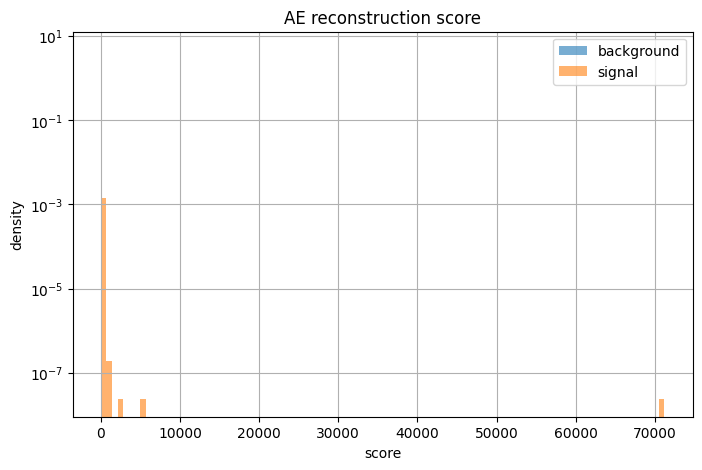


AE reconstruction score ROC
AUC: 0.8409908564147274
AUC inverted: 0.1590091435852726
Best AUC: 0.8409908564147274


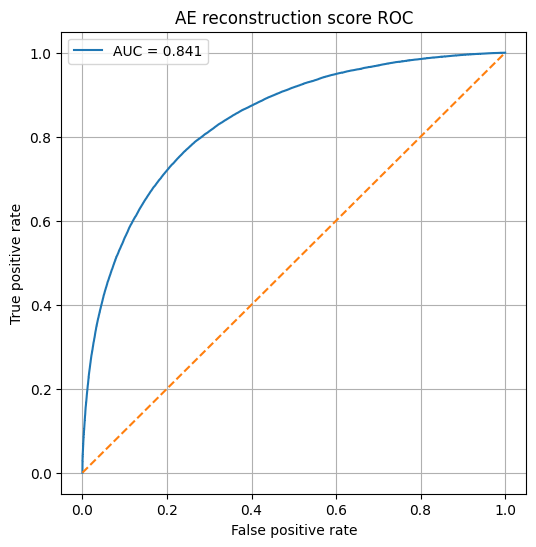

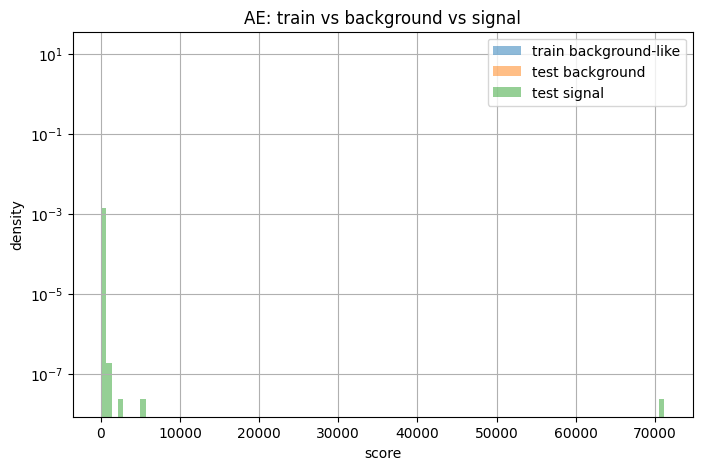

Train vs test background AUC: 0.5084224141
Train vs test background AUC inverted: 0.4915775859
Best train-vs-test-background AUC: 0.5084224141


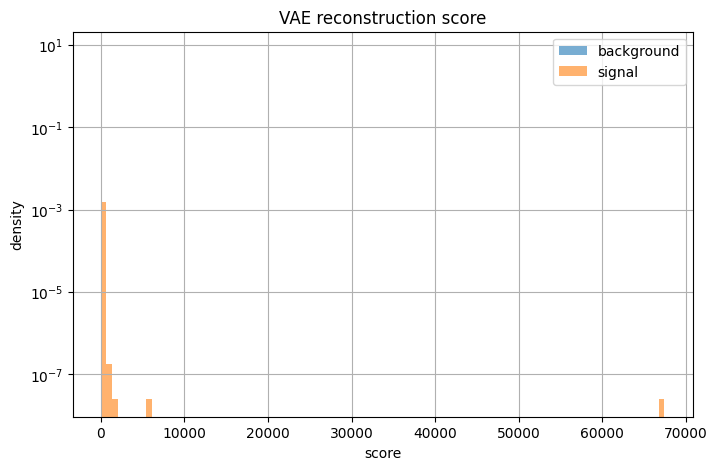


VAE reconstruction ROC
AUC: 0.8382788730635101
AUC inverted: 0.16172112693648982
Best AUC: 0.8382788730635101


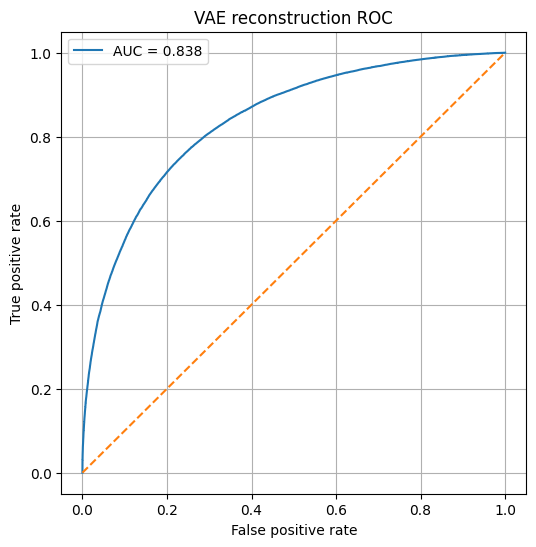

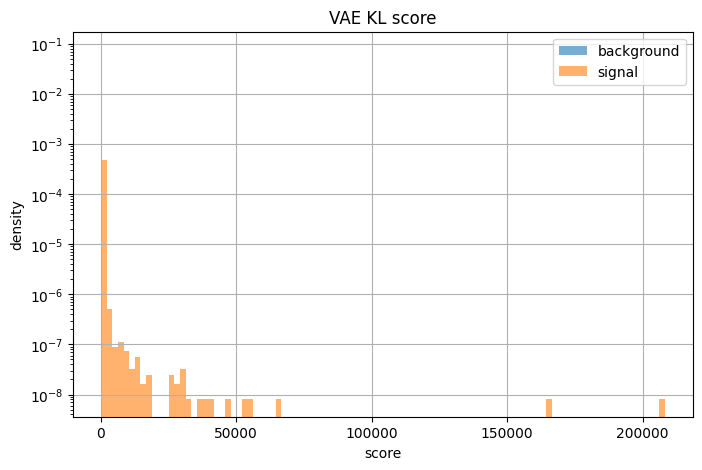


VAE KL ROC
AUC: 0.8205977509892027
AUC inverted: 0.1794022490107974
Best AUC: 0.8205977509892027


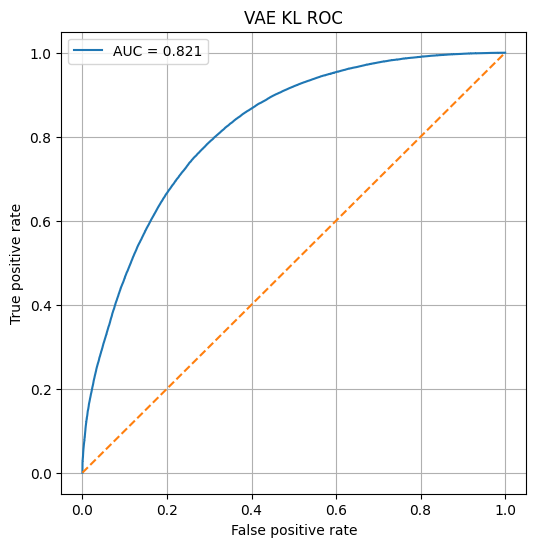

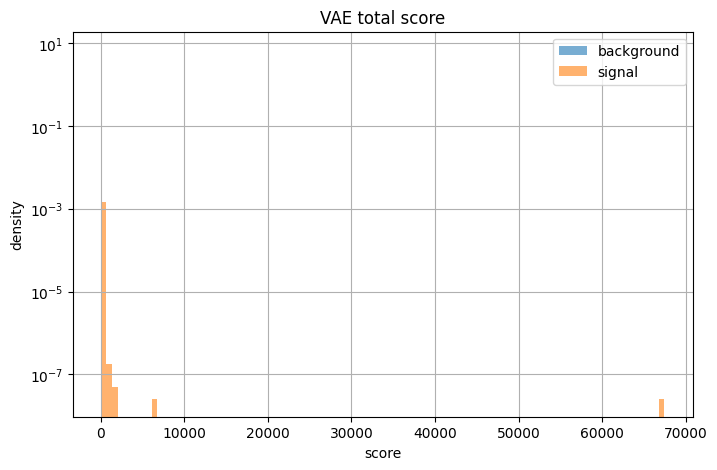


VAE total ROC
AUC: 0.8477047376936488
AUC inverted: 0.15229526230635101
Best AUC: 0.8477047376936488


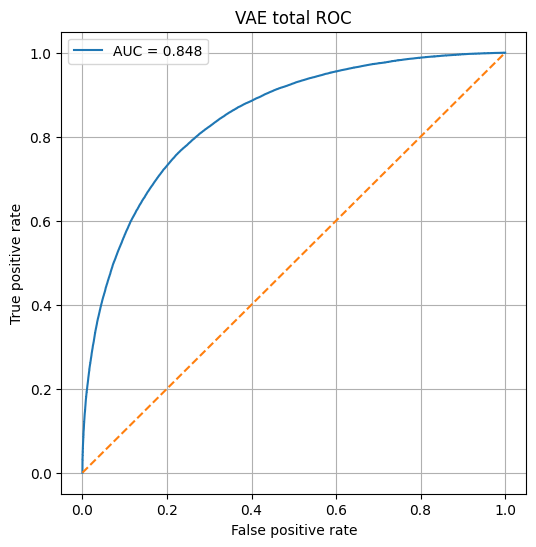

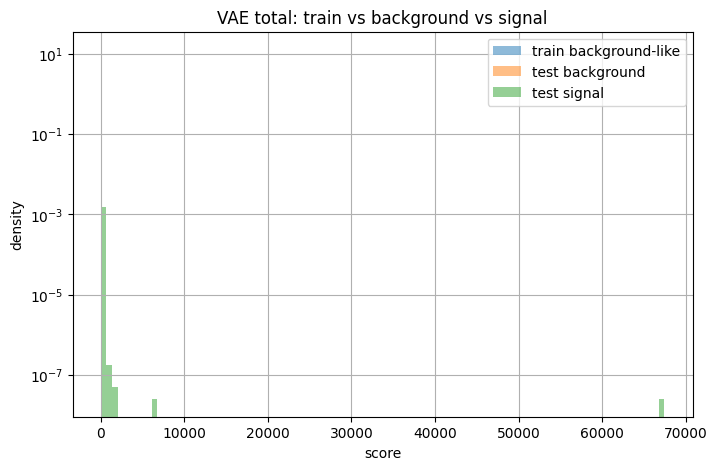

Train vs test background AUC: 0.50762049335
Train vs test background AUC inverted: 0.49237950664999997
Best train-vs-test-background AUC: 0.50762049335


In [23]:
def evaluate_binary_scores(bg_scores, sig_scores, title):
    y_true = np.concatenate([np.zeros_like(bg_scores), np.ones_like(sig_scores)])
    y_score = np.concatenate([bg_scores, sig_scores])

    auc = roc_auc_score(y_true, y_score)
    auc_inv = roc_auc_score(y_true, -y_score)
    best_auc = max(auc, auc_inv)

    print("\n" + title)
    print("AUC:", auc)
    print("AUC inverted:", auc_inv)
    print("Best AUC:", best_auc)

    if auc_inv > auc:
        plot_score = -y_score
        label = f"AUC inverted = {auc_inv:.3f}"
    else:
        plot_score = y_score
        label = f"AUC = {auc:.3f}"

    fpr, tpr, _ = roc_curve(y_true, plot_score)

    plt.figure(figsize=(6, 6))
    plt.plot(fpr, tpr, label=label)
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False positive rate")
    plt.ylabel("True positive rate")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

    return auc, auc_inv, best_auc


def plot_score_distribution(bg_scores, sig_scores, title):
    plt.figure(figsize=(8, 5))
    plt.hist(bg_scores, bins=100, density=True, alpha=0.6, label="background")
    plt.hist(sig_scores, bins=100, density=True, alpha=0.6, label="signal")
    plt.yscale("log")
    plt.xlabel("score")
    plt.ylabel("density")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()


def compare_train_bg_sig(train_scores, bg_scores, sig_scores, title):
    plt.figure(figsize=(8, 5))
    plt.hist(train_scores, bins=100, density=True, alpha=0.5, label="train background-like")
    plt.hist(bg_scores, bins=100, density=True, alpha=0.5, label="test background")
    plt.hist(sig_scores, bins=100, density=True, alpha=0.5, label="test signal")
    plt.yscale("log")
    plt.xlabel("score")
    plt.ylabel("density")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

    y_bg_check = np.concatenate([np.zeros_like(train_scores), np.ones_like(bg_scores)])
    s_bg_check = np.concatenate([train_scores, bg_scores])

    auc_tb = roc_auc_score(y_bg_check, s_bg_check)
    auc_tb_inv = roc_auc_score(y_bg_check, -s_bg_check)

    print("Train vs test background AUC:", auc_tb)
    print("Train vs test background AUC inverted:", auc_tb_inv)
    print("Best train-vs-test-background AUC:", max(auc_tb, auc_tb_inv))


plot_score_distribution(ae_scores_bg, ae_scores_sig, "AE reconstruction score")
ae_auc, ae_auc_inv, ae_best_auc = evaluate_binary_scores(ae_scores_bg, ae_scores_sig, "AE reconstruction score ROC")
compare_train_bg_sig(ae_scores_train, ae_scores_bg, ae_scores_sig, "AE: train vs background vs signal")

plot_score_distribution(vae_scores_bg_reco, vae_scores_sig_reco, "VAE reconstruction score")
vae_reco_auc, vae_reco_auc_inv, vae_reco_best_auc = evaluate_binary_scores(vae_scores_bg_reco, vae_scores_sig_reco, "VAE reconstruction ROC")

plot_score_distribution(vae_scores_bg_kl, vae_scores_sig_kl, "VAE KL score")
vae_kl_auc, vae_kl_auc_inv, vae_kl_best_auc = evaluate_binary_scores(vae_scores_bg_kl, vae_scores_sig_kl, "VAE KL ROC")

plot_score_distribution(vae_scores_bg_total, vae_scores_sig_total, "VAE total score")
vae_total_auc, vae_total_auc_inv, vae_total_best_auc = evaluate_binary_scores(vae_scores_bg_total, vae_scores_sig_total, "VAE total ROC")
compare_train_bg_sig(vae_scores_train_total, vae_scores_bg_total, vae_scores_sig_total, "VAE total: train vs background vs signal")

## 17. Ablation rapida: solo tracks aggregate

In [24]:
A_train_tracks_only = build_aggregate_matrix(X_jets_train, X_tracks_train, mask_train, use_jets=False, use_tracks=True)
A_bg_tracks_only = build_aggregate_matrix(X_jets_bg, X_tracks_bg, mask_bg, use_jets=False, use_tracks=True)
A_sig_tracks_only = build_aggregate_matrix(X_jets_sig_eval, X_tracks_sig_eval, mask_sig_eval, use_jets=False, use_tracks=True)

m = A_train_tracks_only.mean(axis=0, keepdims=True)
s = A_train_tracks_only.std(axis=0, keepdims=True)
s = np.maximum(s, 1e-8)

A_train_tracks_only_norm = ((A_train_tracks_only - m) / s).astype(np.float32)
A_bg_tracks_only_norm = ((A_bg_tracks_only - m) / s).astype(np.float32)
A_sig_tracks_only_norm = ((A_sig_tracks_only - m) / s).astype(np.float32)

print("Track-only shapes:", A_train_tracks_only_norm.shape, A_bg_tracks_only_norm.shape, A_sig_tracks_only_norm.shape)

X_clf_to = np.concatenate([A_bg_tracks_only_norm, A_sig_tracks_only_norm], axis=0)
y_clf_to = np.concatenate([
    np.zeros(A_bg_tracks_only_norm.shape[0], dtype=np.int64),
    np.ones(A_sig_tracks_only_norm.shape[0], dtype=np.int64),
])

X_tr, X_te, y_tr, y_te = train_test_split(X_clf_to, y_clf_to, test_size=0.3, random_state=42, stratify=y_clf_to)

clf_to = LogisticRegression(max_iter=3000)
clf_to.fit(X_tr, y_tr)
proba_to = clf_to.predict_proba(X_te)[:, 1]
auc_track_only_logreg = roc_auc_score(y_te, proba_to)

print("Track-only supervised logistic regression AUC:", auc_track_only_logreg)

C:\Users\andre\AppData\Local\Temp\ipykernel_13344\4191157580.py:11: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(valid_vals, axis=1, keepdims=True)
c:\Users\andre\Desktop\You_better_code\advanceml\.venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\andre\AppData\Local\Temp\ipykernel_13344\4191157580.py:13: RuntimeWarning: All-NaN slice encountered
  median = np.nanmedian(valid_vals, axis=1, keepdims=True)
c:\Users\andre\Desktop\You_better_code\advanceml\.venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1593: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,
C:\Users\andre\AppData\Local\Temp\ipykernel_13344\4191157580.py:15: RuntimeWarning: All-NaN slice encountered
  maxv = np.nanmax(valid_vals, axis=1, keepdims=True)


Track-only shapes: (100000, 61) (100000, 61) (59644, 61)
Track-only supervised logistic regression AUC: 0.9894677834031028


## 18. Salvataggio

In [25]:
torch.save(
    {
        "model_state_dict": ae_model.state_dict(),
        "input_dim": input_dim,
        "latent_dim": ae_latent_dim,
        "aggregate_feature_names": aggregate_feature_names,
        "agg_mean": agg_mean,
        "agg_std": agg_std,
        "train_losses": ae_train_losses,
        "val_losses": ae_val_losses,
        "auc": ae_auc,
        "auc_inv": ae_auc_inv,
        "best_auc": ae_best_auc,
    },
    OUTPUT_DIR / "clean_aggregate_ae.pt",
)

torch.save(
    {
        "model_state_dict": vae_model.state_dict(),
        "input_dim": input_dim,
        "latent_dim": vae_latent_dim,
        "beta": vae_beta,
        "aggregate_feature_names": aggregate_feature_names,
        "agg_mean": agg_mean,
        "agg_std": agg_std,
        "history": vae_history,
        "reco_auc": vae_reco_auc,
        "kl_auc": vae_kl_auc,
        "total_auc": vae_total_auc,
        "reco_best_auc": vae_reco_best_auc,
        "kl_best_auc": vae_kl_best_auc,
        "total_best_auc": vae_total_best_auc,
    },
    OUTPUT_DIR / "clean_aggregate_vae.pt",
)

np.savez_compressed(
    OUTPUT_DIR / "clean_ae_vae_scores.npz",
    ae_scores_train=ae_scores_train,
    ae_scores_bg=ae_scores_bg,
    ae_scores_sig=ae_scores_sig,
    vae_scores_train_reco=vae_scores_train_reco,
    vae_scores_train_kl=vae_scores_train_kl,
    vae_scores_train_total=vae_scores_train_total,
    vae_scores_bg_reco=vae_scores_bg_reco,
    vae_scores_bg_kl=vae_scores_bg_kl,
    vae_scores_bg_total=vae_scores_bg_total,
    vae_scores_sig_reco=vae_scores_sig_reco,
    vae_scores_sig_kl=vae_scores_sig_kl,
    vae_scores_sig_total=vae_scores_sig_total,
    aggregate_feature_names=np.array(aggregate_feature_names, dtype=object),
    auc_logreg=np.array(auc_logreg, dtype=np.float32),
    auc_track_only_logreg=np.array(auc_track_only_logreg, dtype=np.float32),
    ae_auc=np.array(ae_auc, dtype=np.float32),
    ae_auc_inv=np.array(ae_auc_inv, dtype=np.float32),
    ae_best_auc=np.array(ae_best_auc, dtype=np.float32),
    vae_reco_auc=np.array(vae_reco_auc, dtype=np.float32),
    vae_reco_auc_inv=np.array(vae_reco_auc_inv, dtype=np.float32),
    vae_reco_best_auc=np.array(vae_reco_best_auc, dtype=np.float32),
    vae_kl_auc=np.array(vae_kl_auc, dtype=np.float32),
    vae_kl_auc_inv=np.array(vae_kl_auc_inv, dtype=np.float32),
    vae_kl_best_auc=np.array(vae_kl_best_auc, dtype=np.float32),
    vae_total_auc=np.array(vae_total_auc, dtype=np.float32),
    vae_total_auc_inv=np.array(vae_total_auc_inv, dtype=np.float32),
    vae_total_best_auc=np.array(vae_total_best_auc, dtype=np.float32),
)

config = {
    "USE_DISPLACED_PT_FRACTION": USE_DISPLACED_PT_FRACTION,
    "EVAL_ONLY_TRUE_DISPLACED_SIGNAL": EVAL_ONLY_TRUE_DISPLACED_SIGNAL,
    "USE_JET_FEATURES": USE_JET_FEATURES,
    "USE_TRACK_AGGREGATES": USE_TRACK_AGGREGATES,
    "jet_features": jet_features,
    "track_features": track_features,
    "processed_files": {k: str(v) for k, v in processed_files.items()},
    "max_jets_map": max_jets_map,
    "ae_latent_dim": ae_latent_dim,
    "vae_latent_dim": vae_latent_dim,
    "vae_beta": vae_beta,
    "auc_logreg": float(auc_logreg),
    "auc_track_only_logreg": float(auc_track_only_logreg),
    "ae_best_auc": float(ae_best_auc),
    "vae_reco_best_auc": float(vae_reco_best_auc),
    "vae_kl_best_auc": float(vae_kl_best_auc),
    "vae_total_best_auc": float(vae_total_best_auc),
}

with open(OUTPUT_DIR / "clean_pipeline_config.json", "w") as f:
    json.dump(config, f, indent=2)

print("Saved:")
print(OUTPUT_DIR / "clean_aggregate_ae.pt")
print(OUTPUT_DIR / "clean_aggregate_vae.pt")
print(OUTPUT_DIR / "clean_ae_vae_scores.npz")
print(OUTPUT_DIR / "clean_pipeline_config.json")

Saved:
outputs_clean\clean_aggregate_ae.pt
outputs_clean\clean_aggregate_vae.pt
outputs_clean\clean_ae_vae_scores.npz
outputs_clean\clean_pipeline_config.json
